In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as  sns


UsageError: Line magic function `%matplotlib.pyplot` not found.


In [2]:
data=pd.read_csv('phase_prediction_dataset.csv')
data.head()

,C,Mn,Cr,Ni,Mo,Si,V,Austenitizing_Temp,Cooling_Rate,Grain_Size,Phase
0,0.630467,1.716918,1.102540,1.366429,0.335593,0.460364,0.103613,865.469544,33.072005,7.050779,Martensite
1,0.379159,1.003501,0.599962,0.356574,0.538638,0.455619,0.070727,892.222285,18.346312,16.987326,Martensite
2,0.693948,1.915355,1.292615,1.707520,0.166835,0.201348,0.015011,885.429130,11.433398,19.822789,Martensite
3,0.573026,1.371430,0.437368,0.469286,0.015587,0.118328,0.198194,798.397855,4.272456,10.405843,Bainite
4,0.120633,0.408618,0.853751,0.182875,0.465393,0.251900,0.034955,757.837918,5.177387,17.980244,Bainite


In [4]:
data.shape

(2000, 11)

In [5]:
data.describe()

,C,Mn,Cr,Ni,Mo,Si,V,Austenitizing_Temp,Cooling_Rate,Grain_Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.427128,1.087801,0.783450,1.497161,0.301390,0.350453,0.098686,852.074070,25.350218,12.559357
std,0.217837,0.521733,0.398251,0.865417,0.172705,0.143748,0.056981,58.022752,14.611602,4.340008
min,0.050389,0.201156,0.100440,0.001251,0.000343,0.100007,0.000025,750.129677,0.102526,5.000289
25%,0.233053,0.642485,0.438057,0.762255,0.149867,0.223720,0.048650,802.651809,12.651491,8.873311
50%,0.422008,1.091082,0.776618,1.505281,0.307676,0.351738,0.097988,856.066204,25.346128,12.703579
75%,0.620910,1.542179,1.123676,2.224480,0.446209,0.474763,0.147061,902.885407,38.111393,16.273792
max,0.799566,1.999578,1.499601,2.999931,0.599436,0.599733,0.199989,949.895523,49.977993,19.988172


In [ ]:
data.isnull().sum()

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["Phase_num"] = le.fit_transform(data["Phase"])

print("Classes:", le.classes_)  



Classes: [0 1 2]


In [71]:
x=data.drop(['Phase','Phase_num'],axis=1)

In [72]:
y=data['Phase_num']

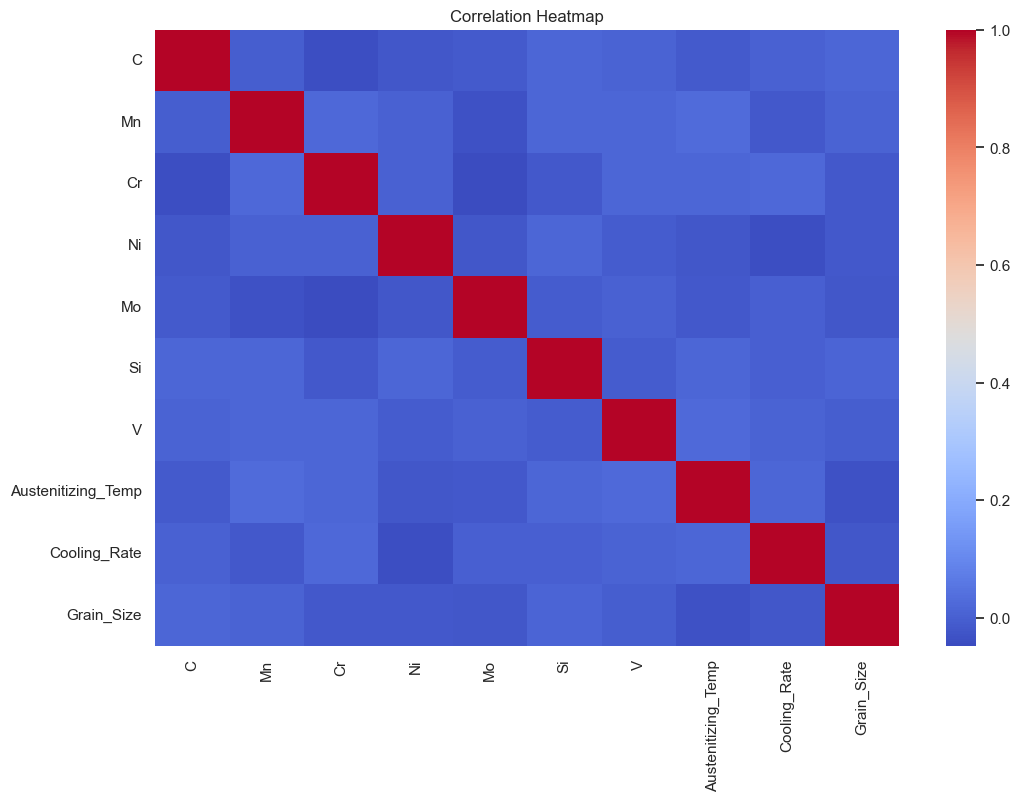

In [73]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(x.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


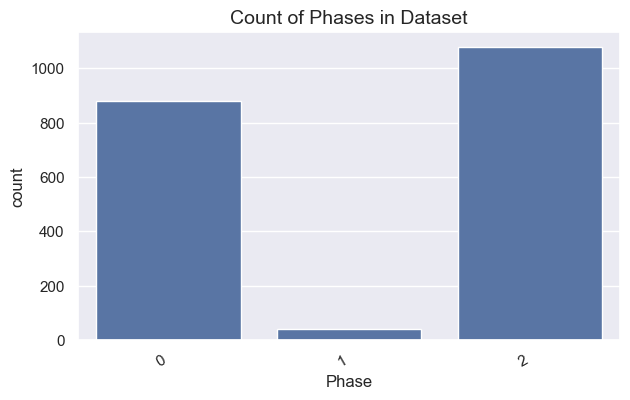

In [74]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(7,4))
ax = sns.countplot(x=data["Phase"])

ax.set_title("Count of Phases in Dataset", fontsize=14)
plt.xticks(rotation=30, ha="right")

plt.show()

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

In [76]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [77]:
model_lr= LinearRegression()
model_lr.fit(x_train,y_train)
predict_lr=model_lr.predict(x_test)
rmse_lr=np.sqrt(mean_squared_error(y_test,predict_lr))
rmse_lr

np.float64(0.7065447700257457)

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(x_train, y_train)

pred_rf = rf.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))


Random Forest Accuracy: 0.97
[[171   0   5]
 [  1   7   0]
 [  6   0 210]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       176
           1       1.00      0.88      0.93         8
           2       0.98      0.97      0.97       216

    accuracy                           0.97       400
   macro avg       0.98      0.94      0.96       400
weighted avg       0.97      0.97      0.97       400



In [79]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(x_train, y_train)

pred_xgb = xgb.predict(x_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))
print(confusion_matrix(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))


XGBoost Accuracy: 0.98
[[172   0   4]
 [  0   8   0]
 [  4   0 212]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       176
           1       1.00      1.00      1.00         8
           2       0.98      0.98      0.98       216

    accuracy                           0.98       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.98      0.98      0.98       400



In [80]:
print("RMSE Scores:")
print("Linear Regression:", rmse_lr)
print("Random Forest:", rmse_rf)
print("xgboost:",rmse_xgb)

RMSE Scores:
Linear Regression: 0.7065447700257457
Random Forest: 0.3390996248236726
xgboost: 0.37189467482250776


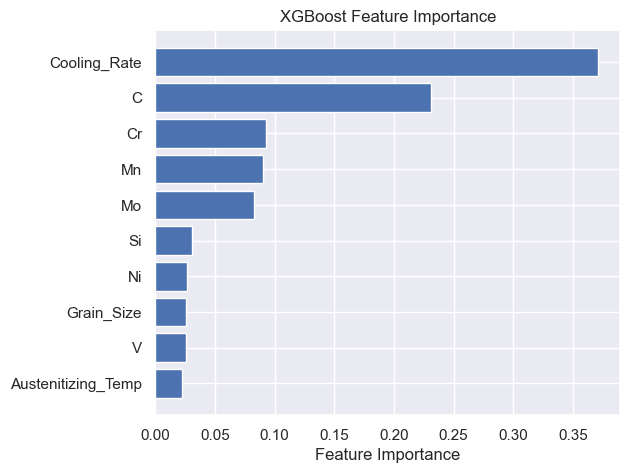

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = xgb.feature_importances_
sorted_idx = importance.argsort()

plt.figure(figsize=(6,5))
plt.barh(x.columns[sorted_idx], importance[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.show()


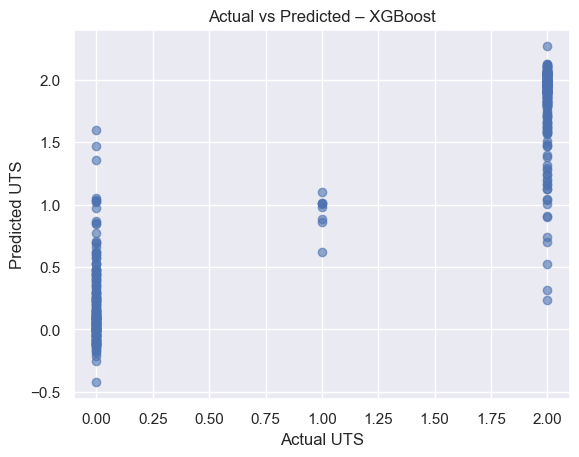

In [49]:
plt.scatter(y_test, pred_xgb, alpha=0.6)
plt.xlabel("Actual ")
plt.ylabel("Predicted phase")
plt.title("Actual vs Predicted – XGBoost")
plt.show()


In [84]:
def predict_phase(input_dict):
    # Prepare empty feature row
    full_input = {col: 0.0 for col in x.columns}
    
    # Fill provided inputs
    for key, value in input_dict.items():
        if key in full_input:
            full_input[key] = value
        else:
            print(f"Warning: {key} is not a valid feature name.")
    
    # Convert to DF
    import pandas as pd
    df_in = pd.DataFrame([full_input])
    
    # Predict
    pred_num = xgb.predict(df_in)[0]
    phase_name = le.inverse_transform([pred_num])[0]
    
    print("Predicted Phase:", phase_name)
    return phase_name


In [85]:
predict_phase({"C": 0.35,
    "Mn": 1.2,
    "Cr": 0.8,
    "Cooling_Rate": 20})

Predicted Phase: 2


np.int8(2)

In [86]:
y

0       2
1       2
2       2
3       0
4       0
       ..
1995    0
1996    0
1997    2
1998    2
1999    2
Name: Phase_num, Length: 2000, dtype: int64